In [2]:
import pandas as pd

# Replace 'creditcard.csv' with your actual filename if different
file_path = '/content/creditcard.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Check the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
# check no. of rows and colums in dataset
rows = df.shape[0]
columns =df.shape[1]
print(f'Number of rows: {rows}')
print(f'Number of columns: {columns}')

Number of rows: 15936
Number of columns: 31


In [4]:
# check for data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15936 entries, 0 to 15935
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    15936 non-null  int64  
 1   V1      15936 non-null  float64
 2   V2      15936 non-null  float64
 3   V3      15936 non-null  float64
 4   V4      15936 non-null  float64
 5   V5      15936 non-null  float64
 6   V6      15936 non-null  float64
 7   V7      15936 non-null  float64
 8   V8      15936 non-null  float64
 9   V9      15936 non-null  float64
 10  V10     15936 non-null  float64
 11  V11     15936 non-null  float64
 12  V12     15936 non-null  float64
 13  V13     15936 non-null  float64
 14  V14     15936 non-null  float64
 15  V15     15936 non-null  float64
 16  V16     15936 non-null  float64
 17  V17     15936 non-null  float64
 18  V18     15936 non-null  float64
 19  V19     15936 non-null  float64
 20  V20     15936 non-null  float64
 21  V21     15936 non-null  float64
 22

In [5]:
# check for missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [6]:
# check for missing cells
df.isnull().sum().sum()

np.int64(8)

In [7]:
# count values of each class
class_value_count = df['Class'].value_counts()
fraud_percent = (class_value_count[1] / df.shape[0]) * 100
print('Count of fraud and non-fraud cases:')
print(class_value_count.to_string())
print(f'\nPercentage of fraud cases: {fraud_percent: .4f}%')

Count of fraud and non-fraud cases:
Class
0.0    15862
1.0       73

Percentage of fraud cases:  0.4581%


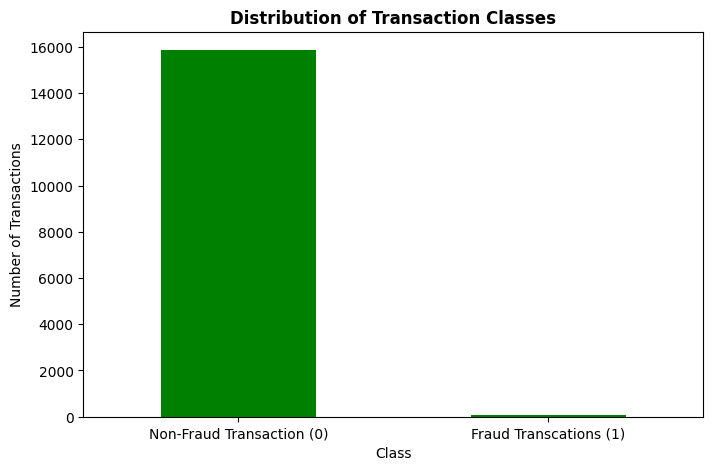

In [8]:
import matplotlib.pyplot as plt

# select column class, get count
counts = df['Class'].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind='bar', color='green')

plt.title('Distribution of Transaction Classes', fontweight='bold')
plt.xticks([0,1],['Non-Fraud Transaction (0)', 'Fraud Transcations (1)'], rotation=0)
plt.ylabel('Number of Transactions')
plt.show()

In [9]:
# group data into fraud vs non-fraud groups
group_data = df.groupby('Class')
# get count, mean, std, min, max, quartiles for each group
summary = group_data[['Amount','Time']].describe()
print(summary)

        Amount                                                             \
         count       mean         std  min     25%    50%    75%      max   
Class                                                                       
0.0    15862.0  66.280151  188.898885  0.0  5.5225  15.95  53.89  7712.43   
1.0       73.0  90.307123  271.634360  0.0  1.0000   1.00  99.99  1809.68   

          Time                                                               \
         count          mean          std    min      25%      50%      75%   
Class                                                                         
0.0    15862.0  12104.432165  8984.508696    0.0  3611.75  10977.0  20601.5   
1.0       73.0  15559.643836  7670.577525  406.0  8528.00  14073.0  21419.0   

                
           max  
Class           
0.0    27370.0  
1.0    27252.0  


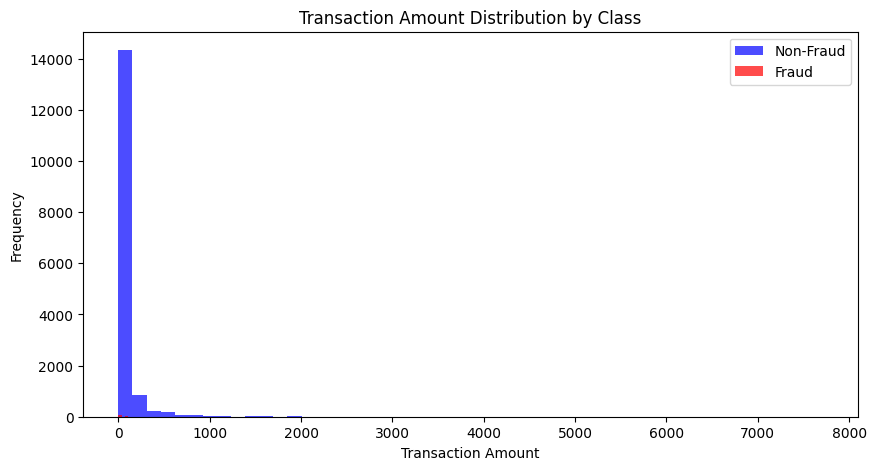

In [10]:
# histogram of Amount by class
import matplotlib.pyplot as plt

amount_non_fraud = df[df['Class']== 0]['Amount']
amount_fraud = df[df['Class']== 1]['Amount']

plt.figure(figsize=(10,5))
plt.hist(amount_non_fraud, bins=50, color='blue', alpha=0.7, label='Non-Fraud')
plt.hist(amount_fraud, bins=50, color='red', alpha=0.7, label='Fraud')
plt.legend()
plt.title('Transaction Amount Distribution by Class')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

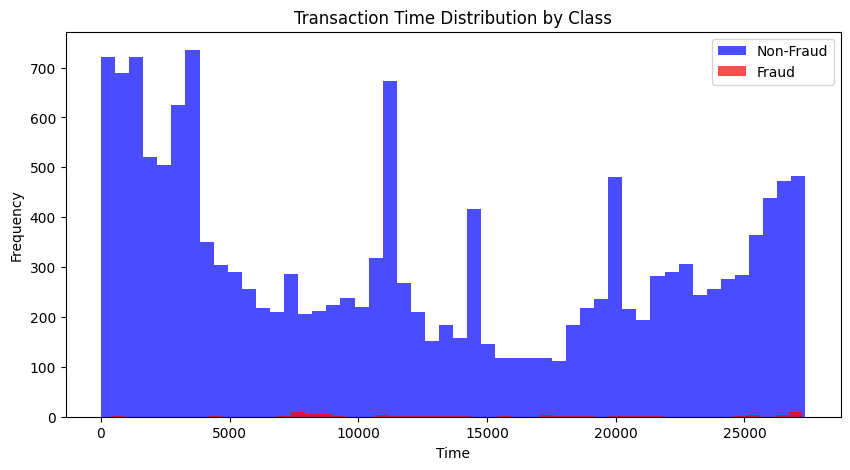

In [11]:
# histogram of Time by class
import matplotlib.pyplot as plt

time_non_fraud = df[df['Class']== 0]['Time']
time_fraud = df[df['Class']== 1]['Time']
plt.figure(figsize=(10,5))
plt.hist(time_non_fraud, bins=50, color='blue', alpha=0.7, label='Non-Fraud')
plt.hist(time_fraud, bins=50, color='red', alpha=0.7, label='Fraud')
plt.legend()
plt.title('Transaction Time Distribution by Class')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_652/3445687958.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([amount_non_fraud, amount_fraud], labels=['Non-Fraud', 'Fraud'], patch_artist=True,


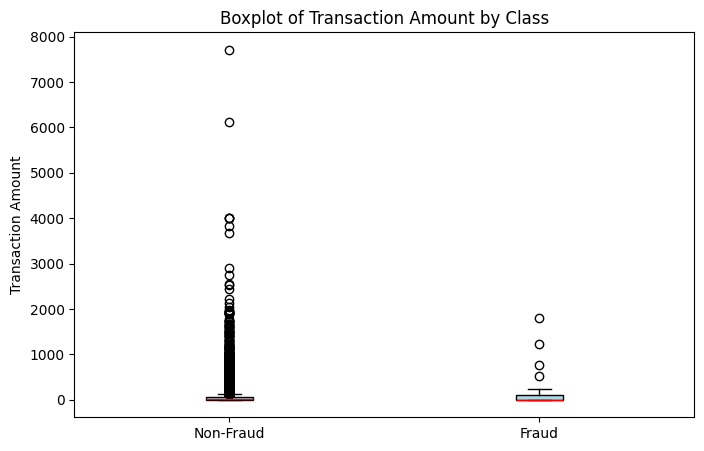

/tmp/ipykernel_652/3445687958.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_non_fraud, time_fraud], labels=['Non-Fraud', 'Fraud'], patch_artist=True,


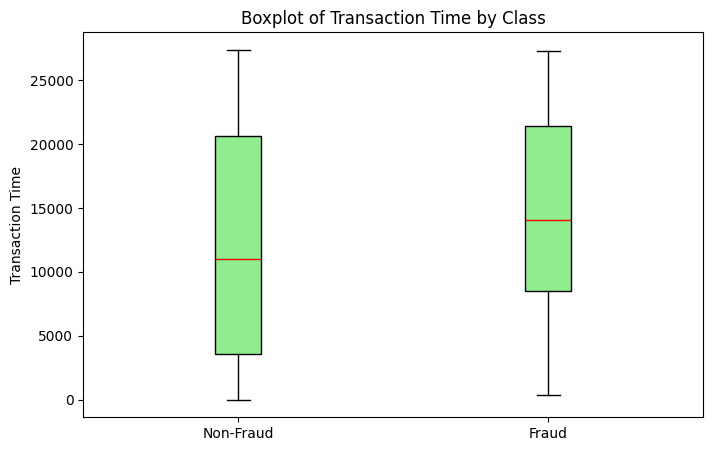

In [12]:
# Boxplot for Amount
import matplotlib.pyplot as plt

amount_non_fraud = df[df['Class'] == 0]['Amount']
amount_fraud = df[df['Class'] == 1]['Amount']
plt.figure(figsize=(8, 5))
plt.boxplot([amount_non_fraud, amount_fraud], labels=['Non-Fraud', 'Fraud'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
plt.title('Boxplot of Transaction Amount by Class')
plt.ylabel('Transaction Amount')
plt.show()

# Boxplot for Time
plt.figure(figsize=(8, 5))
plt.boxplot([time_non_fraud, time_fraud], labels=['Non-Fraud', 'Fraud'], patch_artist=True,
            boxprops=dict(facecolor='lightgreen'), medianprops=dict(color='red'))
plt.title('Boxplot of Transaction Time by Class')
plt.ylabel('Transaction Time')
plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# make copies of original features
amount = df['Amount'].values.reshape(-1,1)
time = df['Time'].values.reshape(-1,1)

scaler = StandardScaler()

# fit and transform the columns
scaled_amount = scaler.fit_transform(amount)
scaled_time = scaler.fit_transform(time)

# apply log transform on amount and then scale it
log_amount = np.log1p(df['Amount'])
scaled_log_amount = scaler.fit_transform(log_amount.values.reshape(-1,1))

# add scaled columns to dataframe
df['Scaled_Amount'] = scaled_amount
df['Scaled_Time'] = scaled_time
df['Scaled_Log_Amount'] = scaled_log_amount

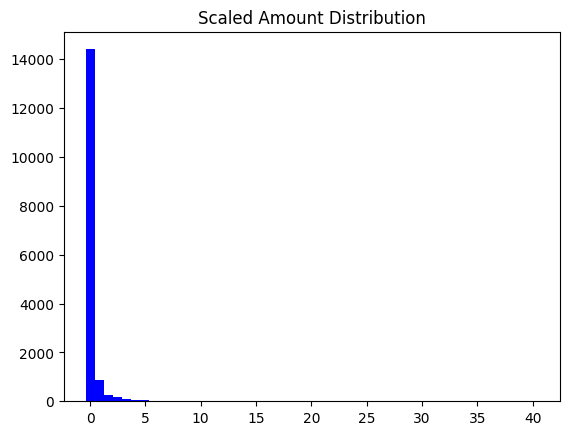

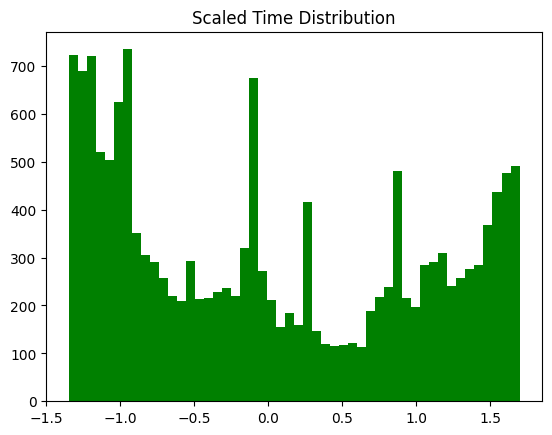

In [14]:
# visualize scaled features

import matplotlib.pyplot as plt

plt.hist(df['Scaled_Amount'], bins=50, color='blue')
plt.title("Scaled Amount Distribution")
plt.show()

plt.hist(df['Scaled_Time'], bins=50, color='green')
plt.title("Scaled Time Distribution")
plt.show()

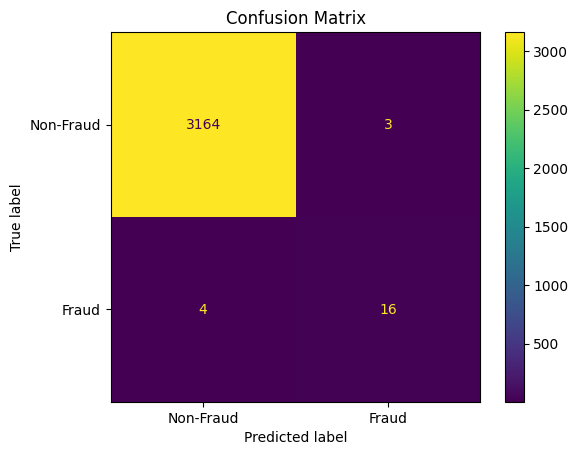

In [15]:
# confusion matrix: shows how many transactions the model correctly predicted as
# fraud or non-fraud and how many it got wrong
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = df.dropna(subset=['Class'])
x = df.drop('Class', axis=1) # all columns except class
y = df['Class']

# split training and testing sets(80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

# predict on test set
y_pred = model.predict(x_test)

# create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix =cm, display_labels=['Non-Fraud', 'Fraud'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Random Forest Accuracy: 0.9987449011609665

Classification Report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00      3167
       Fraud       0.90      0.90      0.90        20

    accuracy                           1.00      3187
   macro avg       0.95      0.95      0.95      3187
weighted avg       1.00      1.00      1.00      3187



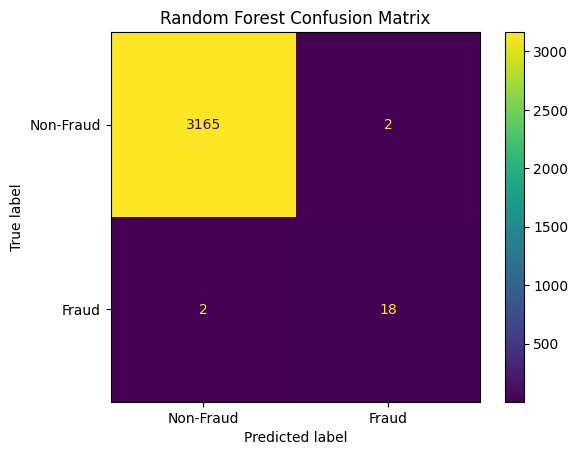

In [16]:
# use random forest to classifier to improve performance, reduce mistakes

# import the model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# create the model
rf_model = RandomForestClassifier(random_state=42)

# train the model
rf_model.fit(x_train, y_train)

# predict using the test set
y_rf_pred = rf_model.predict(x_test)

# evaluate the model:

# Accuracy score
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_rf_pred, target_names=['Non-Fraud','Fraud']))

# confusion matrix
cm = confusion_matrix(y_test, y_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud','Fraud'])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [17]:
# handle class imbalance using SMOTE

from imblearn.over_sampling import SMOTE

# initialize SMOTE with a random seed for reproducibilty
smote = SMOTE(random_state=42)

# resample the training data
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

# train the model on the resampled data
model.fit(x_resampled, y_resampled)

# predict on the original test set
y_pred = model.predict(x_test)

# evalate again
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

Accuracy: 0.998431126451208

Classification Report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00      3167
       Fraud       0.86      0.90      0.88        20

    accuracy                           1.00      3187
   macro avg       0.93      0.95      0.94      3187
weighted avg       1.00      1.00      1.00      3187



In [18]:
# use XGBoost to improve the model

import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# calculate imbalance ratio for scale pos_weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# imitialize the xgboost classifier
xgb_model = xgb.XGBClassifier(
    objective= 'binary:logistic', # binary classification with logistic loss
    eval_metric= 'logloss', # evaluation metric during training
    scale_pos_weight=scale_pos_weight, # adjusts for class imbalance
    random_state=42, # for reproducibilty
    n_estimators=100, # number of trees in the ensemble
    max_depth=6, # maximum depth of each tree
    learning_rate=0.1 # step size shrinkage used in update to prevent overfitting
)

# Train the model on training data
xgb_model.fit(x_train, y_train)

# Predict the labels for the test set
y_pred = xgb_model.predict(x_test)

# Calculate and print accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))

# Generate and print detailed classification metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

XGBoost Accuracy: 0.9987449011609665

Classification Report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00      3167
       Fraud       0.86      0.95      0.90        20

    accuracy                           1.00      3187
   macro avg       0.93      0.97      0.95      3187
weighted avg       1.00      1.00      1.00      3187

